In [10]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle
import os
from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model_shap import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy
from collections import defaultdict
from collections import OrderedDict
import shap
from pytorch_grad_cam import GradCAM
from tangermeme.deep_lift_shap import deep_lift_shap
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute
from tangermeme.ersatz import dinucleotide_shuffle

In [2]:
data_dir = '../Data'
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType)

SL = 5000
CL_max = 10000
BATCH_SIZE = 100

specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

test_dataset = spliceDataset(getDataPointListFull(annotation_test,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

In [11]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

In [24]:
batch, _ = next(iter(test_loader))
background = batch.type(torch.FloatTensor).to(device)
print(background.shape)

torch.Size([100, 4, 15000])


/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [7]:
class WrappedModel(nn.Module):
    def __init__(self, base_model, target_idx):
        super().__init__()
        self.base_model = base_model
        self.target_idx = target_idx

    def forward(self, x):
        out = self.base_model(x)
        scalar = out[:, self.target_idx[0], self.target_idx[1]]
        return scalar.unsqueeze(1) # shape batch_size,n_targets


In [20]:
for model in models:
    with torch.no_grad():
        baseline_preds = model(torch.tensor(background)).mean(dim=0)
    break


/var/folders/b4/wk8m28x57xn6sy326ngv7k5m0000gn/T/ipykernel_38795/3494181121.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  baseline_preds = model(torch.tensor(background)).mean(dim=0)


tensor([[  2.1886,   2.2261,   2.1950,  ...,   1.4233,   1.3681,   1.3682],
        [-10.0735, -10.2404, -10.7162,  ..., -10.2628, -10.0971,  -9.7080],
        [-13.4132, -13.7372, -13.7274,  ..., -11.6634, -11.3224, -10.9879]])


In [22]:
print(baseline_preds[1,9290])

tensor(-19.6174)


In [11]:
explainer = []
for model in models:
    wrapped_model = WrappedModel(model, target_idx=(1, 9290))
    e = shap.DeepExplainer(wrapped_model,background)
    break


torch.Size([100])
torch.Size([100, 1])


In [4]:
specific_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
specific_dataset.seqData = seqData
specific_loader = torch.utils.data.DataLoader(specific_dataset, batch_size=38, shuffle=False, num_workers=0, pin_memory=True)
specific_results, specific_target = next(iter(specific_loader))
specific_results = specific_results.type(torch.FloatTensor).to('cpu')
specific_results = torch.unsqueeze(specific_results[4],dim=0)
print(specific_results.shape)
print(np.where(specific_target[4,1,:]==1))

torch.Size([1, 4, 15000])
(array([ 9290, 14071]),)


/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [5]:
for model in models:
    output_old = model(specific_results)
    break
print(output_old[0,1,4290])

tensor(0.9927, grad_fn=<SelectBackward0>)


In [8]:
for model in models:
    output_new = model(specific_results)
    break

In [9]:
print(torch.equal(output_old,output_new))

True


In [13]:
shap_value = e.shap_values(specific_results,check_additivity=False)

torch.Size([200])
torch.Size([200, 1])


In [28]:
for model in models:
    output = model(specific_results)
    break
output_pred = output[0,1,9290]
print(output_pred)
print(baseline_preds[1,9290])
print(np.sum(shap_value))

tensor(5.7105, grad_fn=<SelectBackward0>)
tensor(-19.6174)
-14.823914997018841


-14.823914997018841
(1, 4, 15000)
-14.823914997018841


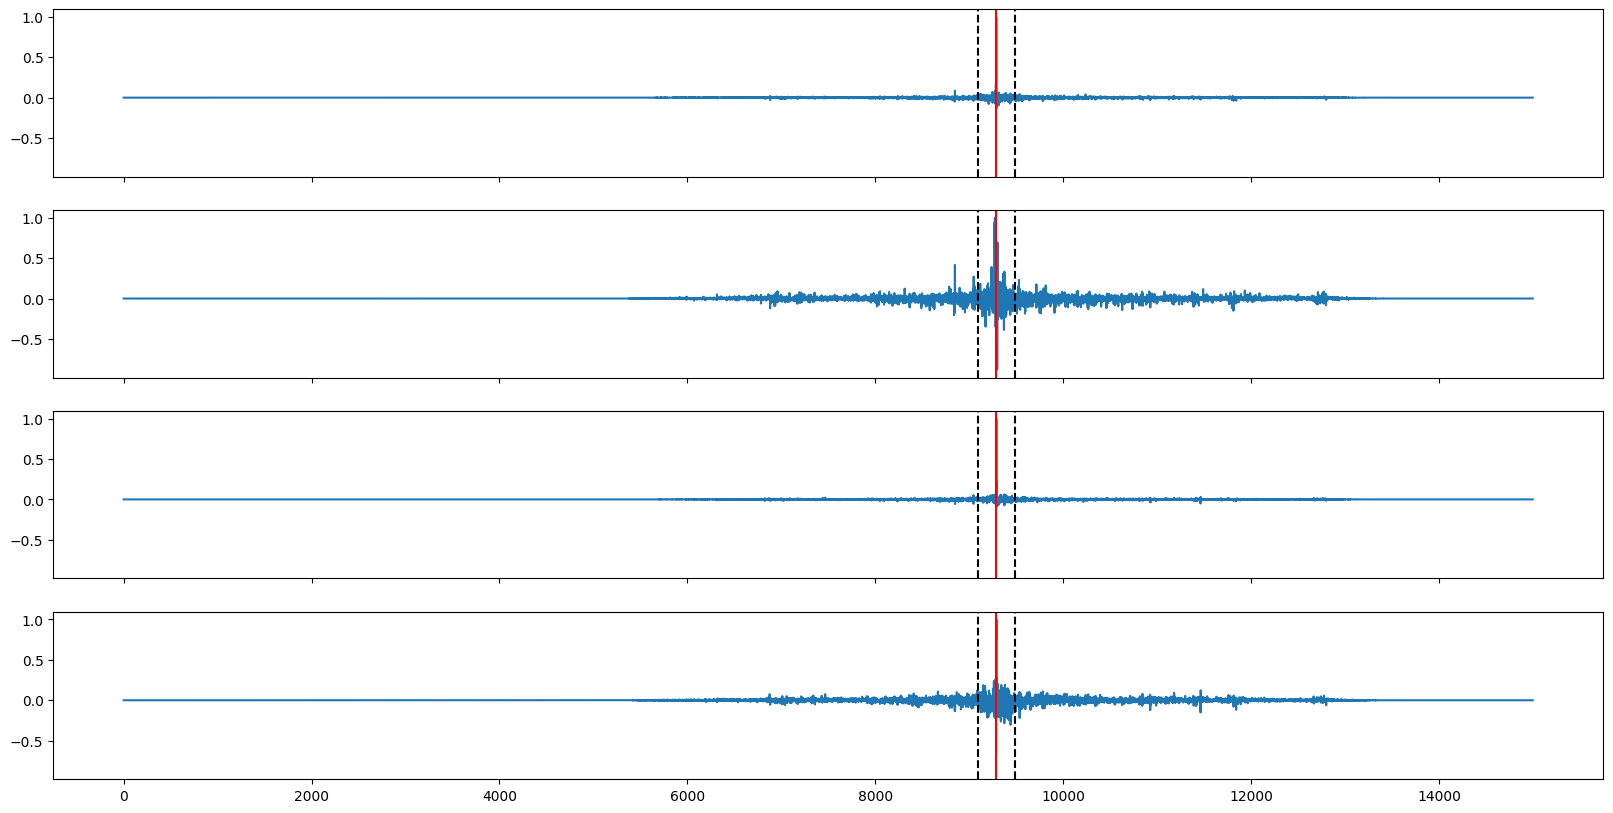

In [23]:
b = np.sum(shap_value[0,:,:,0])
shap_shap = shap_value[:,:,:,0] 
# shap_shap = shap_value[:,:,:,0]
print(b)
print(shap_shap.shape)
print(np.sum(shap_shap[0,:,:]))

fig, axs = plt.subplots(4, figsize=(20,10),sharex=True, sharey=True)
for i in range(4):
    # shap_shap[0,i,:] /= np.max(shap_shap[0,i,:])
    axs[i].plot(shap_shap[0,i,:])
    # axs[i].set_xlim(9290-200,9290+200)
    axs[i].axvline(9290,color='red')
    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

# fig = plt.figure(figsize=(22,22))
# plt.plot(shap_shap[0,0,:]+shap_shap[0,3,:],label=f'T + A')
# plt.plot(shap_shap[0,1,:]+shap_shap[0,2,:],label=f'G + C')

# plt.xlim(9290-200,9290+200)
# plt.legend()
# plt.show()
# plt.close()

In [47]:
for model in models:
    output = model(specific_results).detach().numpy()
    break

0.9927307


In [106]:
from captum.attr import DeepLiftShap

for model in models:
    print(specific_results.shape,background.shape)
    dl = DeepLiftShap(model)
    attribution = dl.attribute(specific_results,background,target=(1,9290),return_convergence_delta=True)
    break

torch.Size([1, 4, 15000]) torch.Size([100, 4, 15000])


/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:810: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  attributions = super().attribute.__wrapped__(  # type: ignore


In [107]:
print(attribution)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], grad_fn=<MeanBackward1>), tensor([-0.9834, -0.9963, -0.9832, -0.9862, -0.9531, -0.9464, -0.9872, -0.9643,
        -0.9741, -0.9723, -0.9913, -0.9873, -0.9718, -0.9707, -0.9849, -0.9750,
        -0.9882, -0.9931, -0.9870, -0.9721, -0.9653, -0.9648, -1.0062, -0.9769,
        -0.9764, -0.9646, -1.0005, -0.9437, -0.9917, -0.9828, -0.9856, -0.9902,
        -0.9704, -0.9713, -0.9806, -0.9859, -0.9819, -0.9854, -0.9832, -0.9712,
        -0.9778, -0.9897, -0.9841, -0.9820, -0.9875, -0.9670, -0.9707, -0.9719,
        -0.9801, -0.9891, -0.9713, -0.9810, -0.9815, -0.9772, -0.9814, -0.9896,
        -0.9932, -0.9806, -0.9655, -0.9838, -0.9902, -0.9781, -0.9749, -0.9780,
        -0.9723, -0.9590, -0.9678, -0.9635, -0.9747, -0.9812, -0.9870, -0.9403,
        -1.0009, -0.9614, -0.9821, -0.9861, -0.9709, -0.9609, -0.9757, -0.9903,
       

In [80]:
print(np.sum(attribution.detach().cpu().numpy(),axis=(1,2)))

[5.7492995]


In [35]:
mask = specific_results.detach().numpy().astype(bool)

In [1]:
captum_shap = attribution.detach().cpu().numpy()
captum_shap = captum_shap * mask
print(captum_shap.shape)
print(np.sum(captum_shap, axis=(1,2)))

fig, axs = plt.subplots(4, figsize=(22,12),sharex=True, sharey=True)
for i in range(4):
    # captum_shap[0,i,:] /= np.max(captum_shap[0,i,:])
    axs[i].plot(captum_shap[0,i,:])
    # axs[i].set_xlim(9290-210,9290+210)
    # axs[i].axvline(9290,color='red')
    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

NameError: name 'attribution' is not defined

# Lets try DeepShap using the Tangermeme library, which seems to have better documentation


In [6]:
from tangermeme.ersatz import substitute
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import dinucleotide_shuffle
X = random_one_hot((1, 4, 2114), random_state=0).type(torch.float32)
X = substitute(X, "AGATAAG")
X_ref = dinucleotide_shuffle(X, n=20, random_state=0)
print(X.shape,X_ref.shape)
input_diff = (X-X_ref[0])
print(input_diff.shape)
for model in models:
    output_og = model(specific_results)
    break
print(output_og.shape)

torch.Size([1, 4, 2114]) torch.Size([1, 20, 4, 2114])
torch.Size([20, 4, 2114])
torch.Size([1, 3, 5000])


In [22]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K_FullInit(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]
new_state_dict = []
if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            parts = k.split(".")[1:]
            if parts[0] == "res_layers":
  
                new_key = ".".join([parts[0], parts[1]] + parts[3:])
            else:
                new_key = k[7:]  # leave other keys untouched
            new_state_dict[new_key] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

In [12]:
test = random_one_hot((1,4,15000),random_state=0).type(torch.float32)
X_ref = dinucleotide_shuffle(specific_results,n=20,random_state=0)
_nonlinear = lambda x, grad_input, grad_output: grad_input
additional_nonlinear_ops = {torch.nn.ReLU: _nonlinear}
for model in models:
    wrapped_model = WrappedModel(model, target_idx=(1, 4290))
    # y, y_ref = wrapped_model(specific_results), wrapped_model(X_ref[0])
    X_attr = deep_lift_shap(model=wrapped_model,X=specific_results,device='cpu',random_state=0,print_convergence_deltas=True)
    output = wrapped_model(specific_results)
    break
print(output)
# output_diff = (y-y_ref)[:,0]
# input_diff = (specific_results - X_ref[0])
# convergence_t = abs(output_diff - torch.sum(input_diff * X_attr[0], dim=(1, 2))).numpy(force=True)
# print(convergence_t)

tensor([0.7933, 0.7990, 0.7759, 0.7775, 0.7776, 0.7681, 0.7705, 0.7786, 0.7817,
        0.7762, 0.7917, 0.7617, 0.7785, 0.7386, 0.7678, 0.7820, 0.9125, 0.7450,
        0.7544, 0.7582], grad_fn=<AbsBackward0>)
tensor([[0.9927]], grad_fn=<UnsqueezeBackward0>)


/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:439: RuntimeWarning: Convergence deltas too high: tensor([0.7933, 0.7990, 0.7759, 0.7775, 0.7776, 0.7681, 0.7705, 0.7786, 0.7817,
        0.7762, 0.7917, 0.7617, 0.7785, 0.7386, 0.7678, 0.7820, 0.9125, 0.7450,
        0.7544, 0.7582], grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +


In [22]:
# 0.9927 for wrapped model with self.activation1,2

'''tensor([0.9672, 0.9930, 0.9850, 0.9815, 0.9692, 0.9811, 0.9811, 0.9831, 0.9970,
        0.9801, 0.9899, 0.9840, 0.9862, 0.9776, 0.9548, 0.9806, 0.9621, 0.9827,
        0.9796, 0.9709], grad_fn=<AbsBackward0>)'''

'''tensor([0.7933, 0.7873, 0.8400, 0.7635, 0.7864, 0.7944, 0.7694, 0.7826, 0.8344,
        0.7975, 0.7590, 0.7797, 0.7630, 0.7866, 0.7722, 0.7740, 0.7808, 0.7697,
        0.7972, 0.7747], grad_fn=<AbsBackward0>)+'''

[0.9752215  0.9852993  0.98385966 0.98003554 0.97820693 0.9825462
 0.98057055 0.9776697  0.99283195 0.9812242  0.9925059  0.9799956
 0.989386   0.9847394  0.97051847 0.98662364 0.9726027  0.98517644
 0.9803918  0.98375654]


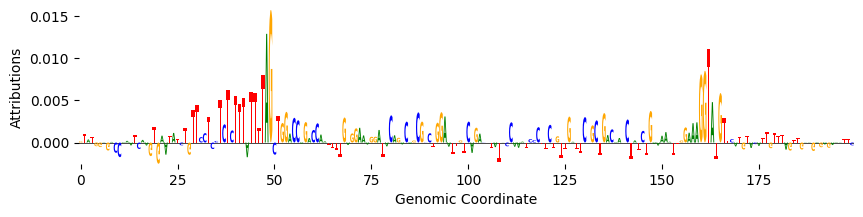

In [17]:
from tangermeme.plot import plot_logo
plt.figure(figsize=(10, 2))
ax = plt.subplot(111)
plot_logo(X_attr[0, :, 9290-50:9290+150], ax=ax)

plt.xlabel("Genomic Coordinate")
plt.ylabel("Attributions")
plt.show()

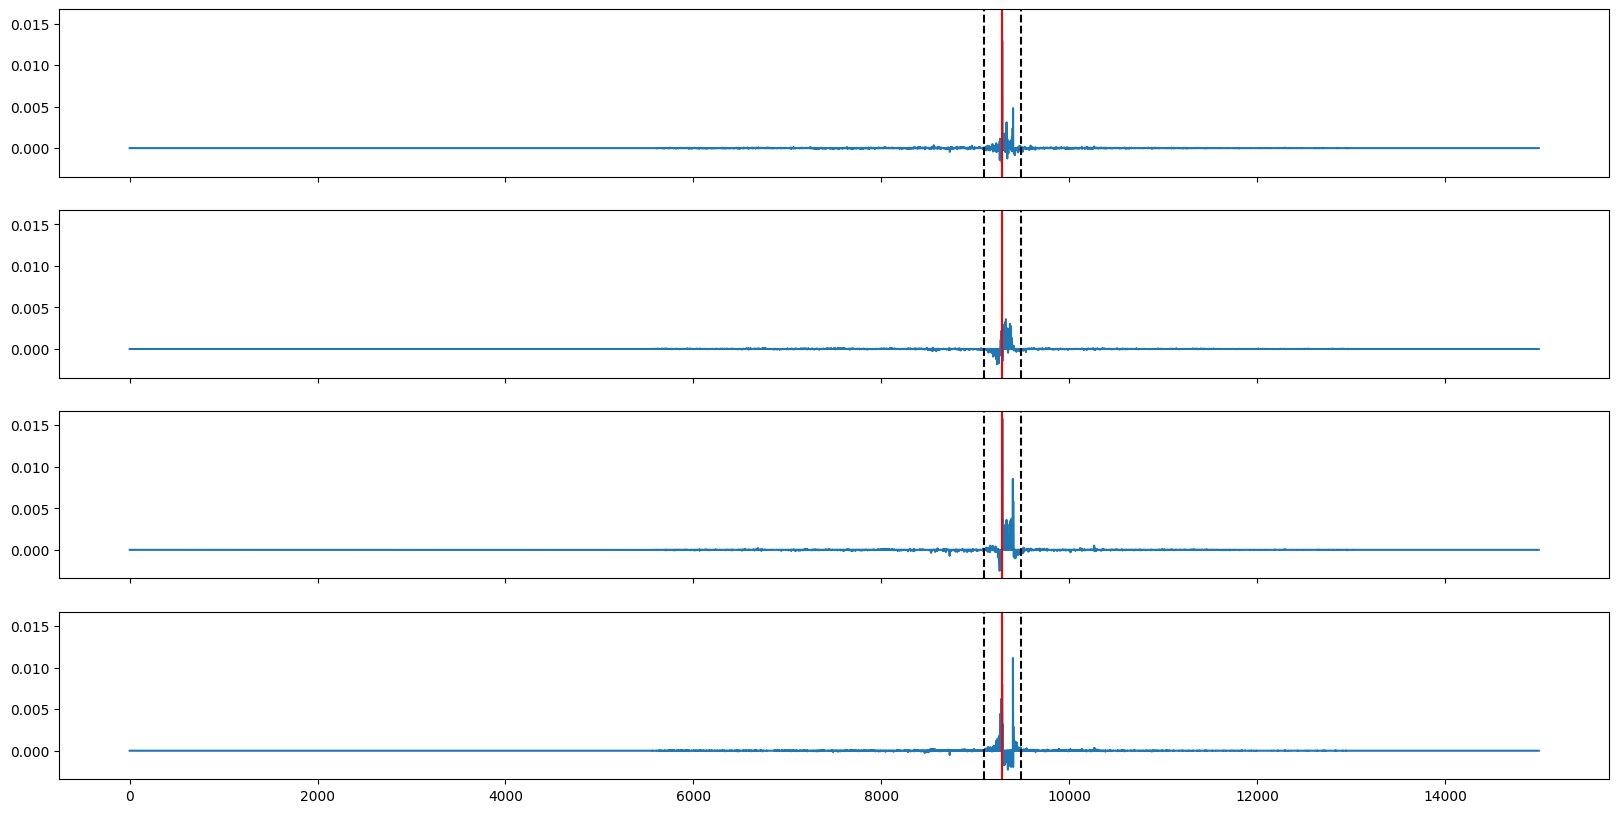

In [18]:
fig, axs = plt.subplots(4, figsize=(20,10),sharex=True, sharey=True)
for i in range(4):
    # shap_shap[0,i,:] /= np.max(shap_shap[0,i,:])
    axs[i].plot(X_attr[0,i,:])
    # axs[i].set_xlim(9290-100,9290+100)
    axs[i].axvline(9290,color='red')

    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

# Going to try implementing Grad-CAM from an exising library to see if its different at all

In [85]:
data_dir = '../Data'
SL=5000
CL_max=10000
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType) 
BATCH_SIZE = 1
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']

In [5]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
            # print(set(state_dict))
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

In [87]:
CL_max = 10000
SL = 5000
device = torch.device('cpu')
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
for i,(batch_chunks,target_chunks) in enumerate(tqdm(test_loader)):
    batch_features = batch_chunks.to(torch.float32).to(device)      # shape: [1, 4, 45000]
    targets = torch.squeeze(target_chunks.to(torch.float32).to(device), dim=0)  # shape: [3, 45000]
    
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())

    if i == 4:
        break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
 11%|█         | 4/38 [00:00<00:00, 96.24it/s]

Transcript spans: 5000 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999


In [94]:
for model in models:
    cam = GradCAM(model=model,target_layers=[model.res_layers[3]])
    output = model(batch_features)
    target_pred = [output[0,1,9290]]
    test = cam(input_tensor=batch_features, targets=target_pred)
    break

TypeError: 'Tensor' object is not callable